In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl.meta.data_processor import DataProcessor

from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline
from pprint import pprint

import sys
sys.path.append("../FinRL")

import itertools

C:\Users\silve\anaconda3\envs\CM3070-FP\lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


warning above is not an issue since we are working with stocks, not futures so the multiplier is 1 by default.

In [2]:
from finrl import config
from finrl import config_tickers
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)
check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

In [3]:
# from config.py, TRAIN_START_DATE is a string
TRAIN_START_DATE

'2014-01-06'

In [4]:
# from config.py, TRAIN_END_DATE is a string
TRAIN_END_DATE

'2020-07-31'

In [3]:
TODAY = datetime.datetime.today().strftime('%Y-%m-%d')

In [17]:
TRAIN_START_DATE = '2008-01-01'
TRAIN_END_DATE = '2023-01-01'
TRADE_START_DATE = '2023-01-01'
TRADE_END_DATE = TODAY

In [18]:
ticker_list = ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SWH', 'TRV', 'UNH', 'V', 'VZ', 'WMT']

In [19]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ticker_list).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (129620, 8)


In [20]:
df

Price,date,close,high,low,open,volume,tic,day
0,2008-01-02,5.855756,6.018650,5.786933,5.988897,1079178800,AAPL,2
1,2008-01-02,32.223793,32.528054,31.988684,32.223793,7934400,AMGN,2
2,2008-01-02,4.812500,4.871500,4.735000,4.767500,277174000,AMZN,2
3,2008-01-02,38.898693,39.874208,38.708163,39.698920,8053700,AXP,2
4,2008-01-02,63.481609,64.375712,63.027225,64.177838,4303000,BA,2
...,...,...,...,...,...,...,...,...
129615,2025-06-12,265.950012,266.079987,258.839996,260.290009,1141400,TRV,3
129616,2025-06-12,318.500000,318.799988,308.510010,311.399994,15906400,UNH,3
129617,2025-06-12,371.399994,374.170013,369.549988,372.230011,4868200,V,3
129618,2025-06-12,43.160000,43.889999,42.910000,43.880001,22346200,VZ,3


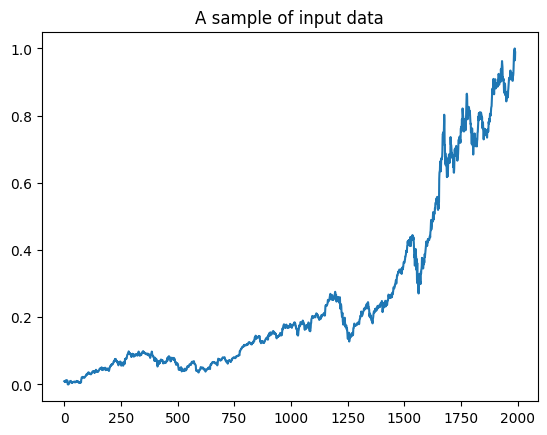

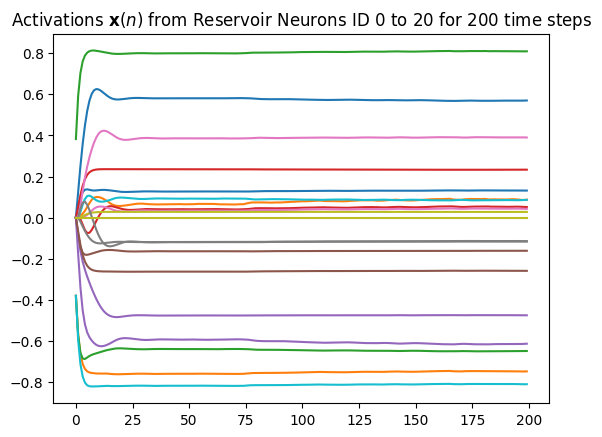

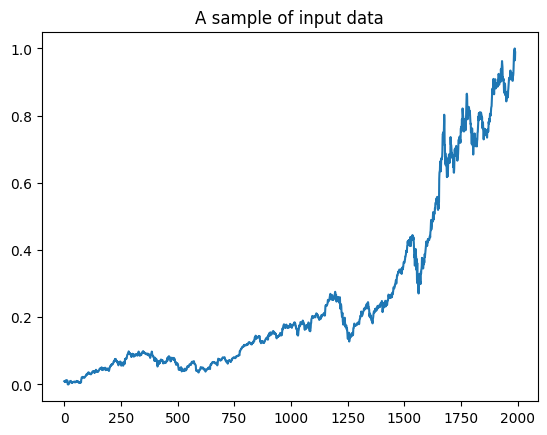

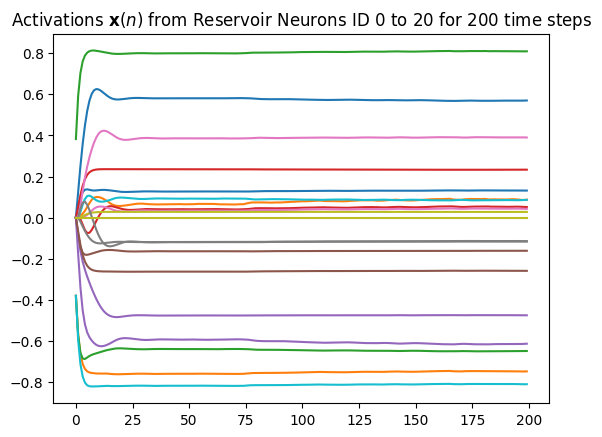

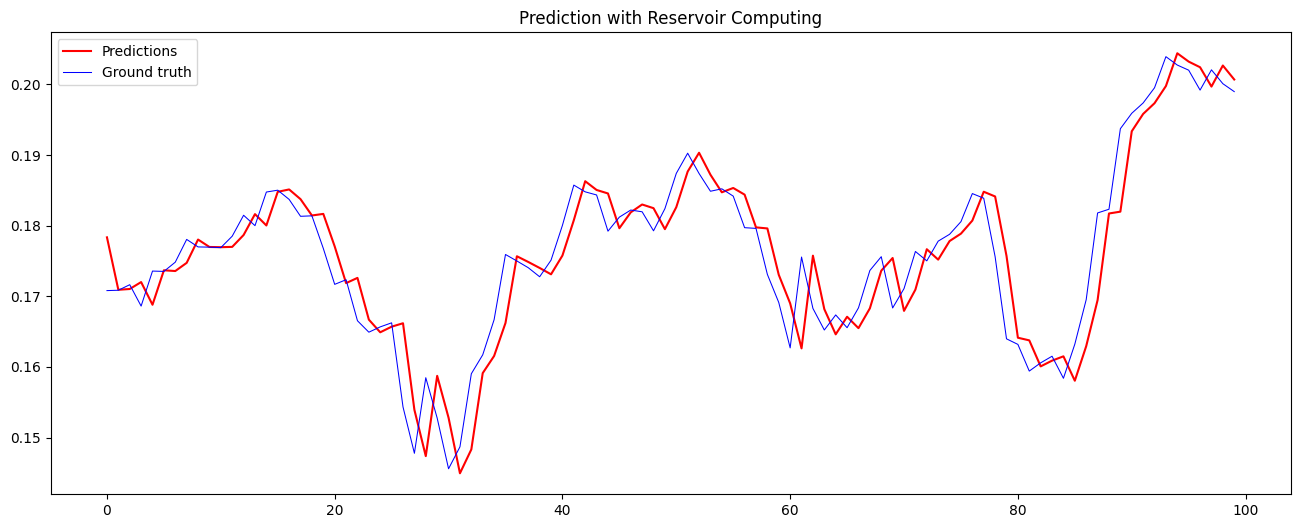

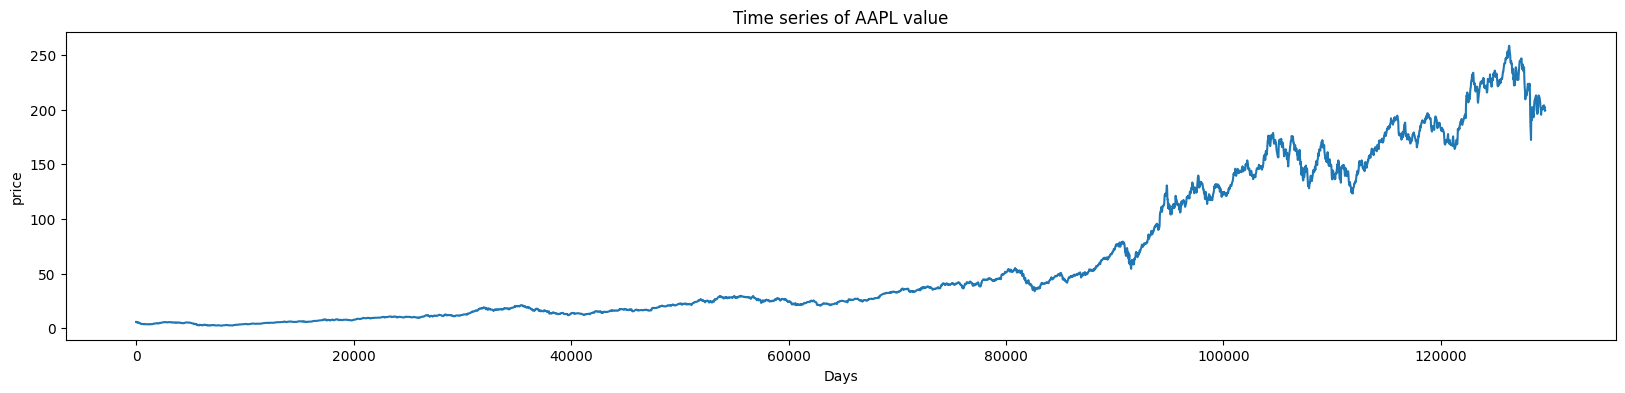

In [22]:
%matplotlib inline
# Create plot
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df[df['tic'] == 'AAPL']['close'])
plt.title("Time series of AAPL value")
plt.xlabel("Days")
plt.ylabel("price")
plt.show()

In [21]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day'], dtype='object', name='Price')

In [6]:
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    tech_indicator_list = INDICATORS,
                    use_vix=True,
                    use_turbulence=True,
                    user_defined_feature = False)

processed = fe.preprocess_data(df)

Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (1990, 8)
Successfully added vix
Successfully added turbulence index


In [7]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])

processed_full = processed_full.fillna(0)

In [8]:
processed_full.sort_values(['date','tic'],ignore_index=True).head(20)

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2014-01-06,AAPL,16.906864,16.996071,16.585779,16.705448,412610800.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,16.906864,16.906864,13.55,0.0
1,2014-01-06,AMGN,82.310516,83.354989,82.049397,83.028592,2838100.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,82.310516,82.310516,13.55,0.0
2,2014-01-06,AMZN,19.681499,19.850000,19.421000,19.792500,63412000.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,19.681499,19.681499,13.55,0.0
3,2014-01-06,AXP,76.188454,76.655610,75.916656,76.188454,2844700.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,76.188454,76.188454,13.55,0.0
4,2014-01-06,BA,118.295074,119.448873,117.773724,119.141191,4196500.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,118.295074,118.295074,13.55,0.0
5,2014-01-06,CAT,65.567970,66.795893,65.375644,66.714524,5233900.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,65.567970,65.567970,13.55,0.0
6,2014-01-06,CRM,53.844185,54.847001,53.645607,54.807285,2532700.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,53.844185,53.844185,13.55,0.0
7,2014-01-06,CSCO,15.506261,15.661253,15.449900,15.471035,34150300.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,15.506261,15.506261,13.55,0.0
8,2014-01-06,CVX,76.355698,76.835926,76.047861,76.706631,4252300.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,76.355698,76.355698,13.55,0.0
9,2014-01-06,DIS,68.926865,69.854129,68.626865,69.572315,6816200.0,0.0,0.0,17.017406,16.675408,0.0,-66.666667,100.0,68.926865,68.926865,13.55,0.0


In [23]:
train = data_split(processed_full, TRAIN_START_DATE,TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE,TRADE_END_DATE)
print(len(train))
print(len(trade))

57710
0


In [24]:
train.tail()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
1989,2021-11-29,TRV,141.272018,143.988082,140.725103,143.988082,1468100.0,0.0,-0.661246,150.314668,141.595626,45.473110,-168.447654,21.181547,146.549654,145.437782,22.959999,70.765948
1989,2021-11-29,UNH,429.644226,430.670797,418.760528,421.621663,4079700.0,0.0,2.329534,443.830127,415.922165,56.526708,-10.477682,1.447591,427.550805,407.654797,22.959999,70.765948
1989,2021-11-29,V,191.175583,196.006355,190.269822,195.762869,14633500.0,0.0,-6.030709,216.329533,188.098320,38.844795,-120.139337,30.552198,208.055695,213.768158,22.959999,70.765948
1989,2021-11-29,VZ,41.367870,41.520016,41.103617,41.327832,18652500.0,0.0,-0.269157,42.559725,40.817442,43.477766,-97.111376,29.587099,41.893181,42.349009,22.959999,70.765948
1989,2021-11-29,WMT,45.142155,45.971384,45.015557,45.892257,33039600.0,0.0,-0.151995,48.417333,44.544230,46.205299,-100.231108,21.692156,46.513856,45.731155,22.959999,70.765948


In [25]:
trade.head()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence


In [26]:
trade.tail()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence


In [27]:
INDICATORS

['macd',
 'boll_ub',
 'boll_lb',
 'rsi_30',
 'cci_30',
 'dx_30',
 'close_30_sma',
 'close_60_sma']

In [28]:
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import mse, nrmse, rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

In [29]:
def normalize_data(train, test):
    data_min = min(train.min(), test.min())
    data_max = max(train.max(), test.max())
    return (train - data_min)/ (data_max - data_min), (test - data_min)/ (data_max - data_min), data_min, data_max

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    mse_score = mse(y_true, y_pred)
    rmse_score = rmse_val  # Change the variable name here
    nmrse_mean = nrmse(y_true, y_pred, norm_value=y_true.mean())
    nmrse_maxmin = nrmse(y_true, y_pred, norm_value=y_true.max() - y_true.min())
    r2 = r2_score(y_true, y_pred)
    return mae, rmse_score, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2

In [30]:
def filter_data(dataframe, ticker, column):
    return dataframe[dataframe['tic'] == ticker][column]

In [31]:
def create_lagged_dataset_from_full(x, x1, n_lags, horizon):
    full = np.concatenate([x, x1])  # Combine to maintain continuity

    X_all, y_all = [], []
    for i in range(len(full) - n_lags - horizon + 1):
        X_all.append(full[i:i + n_lags])
        y_all.append(full[i + n_lags + horizon - 1])

    X_all = np.array(X_all)
    y_all = np.array(y_all).reshape(-1, 1)

    # Determine split index: all points where inputs are from `x` only
    train_cutoff = len(x) - n_lags - horizon + 1

    X_train, y_train = X_all[:train_cutoff], y_all[:train_cutoff]
    X_test, y_test = X_all[train_cutoff:], y_all[train_cutoff:]

    return X_train, y_train, X_test, y_test

In [32]:
def train_rc_model(train, test, ticker, column, horizon):
    
    train = filter_data(train, ticker, column)
    test = filter_data(test, ticker, column)
    
    Dat = np.array(train)
    dat = np.array(test)

    # Set constants
    SEED = 42
    VERBOSE = True
    units = 10000
    z = horizon
    if __name__ == "__main__":
        rpy.set_seed(SEED)
        rpy.verbosity(0)

        if VERBOSE:
            print("Train", Dat.shape)
            print("max:", Dat.max(), "min:", Dat.min())
            print("mean:", Dat.mean(), "std:", Dat.std())

            print("Test", dat.shape)
            print("max:", dat.max(), "min:", dat.min())
            print("mean:", dat.mean(), "std:", dat.std())

        x, x1, minima, maxima = normalize_data(Dat, dat)

        n_lags = z

        X, y, X_test, y_test = create_lagged_dataset_from_full(x, x1, n_lags, z)
        
        #y = np.concatenate((x[z:], x1[:z])).reshape(-1, 1)
        #X_test = x1[:len(X1)-z].reshape(-1, 1)
        #y_test = x1[z:].reshape(-1, 1)
        #X = x.reshape(-1, 1)

        print(X.shape)
        print(y.shape)
        print(X_test.shape)
        print(y_test.shape)

        # Reservoir parameters
        units = 50
        leak_rate = 0.5
        rho = 1.0
        input_scaling = 1.0
        rc_connectivity = 0.15
        input_connectivity = 0.2
        fb_connectivity = 1.1
        regularization_coef = 1e-6
        warmup = 200
        feedback = False

        rng = np.random.default_rng(SEED)
        W = rng.random((units, units)) - 0.5
        input_bias = True  # Set to True or False depending on your choice
        Win = rng.random((units, 1 + int(input_bias))) - 0.5
        Wfb = rng.random((units, 1)) - 0.5

        mask = rng.random((units, units))
        W[mask > rc_connectivity] = 0

        mask = rng.random((units, Win.shape[1]))
        Win[mask > input_connectivity] = 0

        mask = rng.random((units, Wfb.shape[1]))
        Wfb[mask > fb_connectivity] = 0

        Win = Win * input_scaling

        # Calculate the spectral radius
        original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

        # Rescale the matrix to reach the requested spectral radius:
        W = W * (rho / original_spectral_radius)

        # Create a reservoir
        reservoir = Reservoir(
            units,
            lr=leak_rate,
            sr=rho,
            input_bias=input_bias,
            input_scaling=input_scaling,
            rc_connectivity=rc_connectivity,
            input_connectivity=input_connectivity,
            fb_connectivity=fb_connectivity,
        )

        readout = Ridge(ridge=regularization_coef)

        if feedback:
            reservoir = reservoir << readout

        esn = reservoir >> readout

        internal_trained = reservoir.run(X)

        reservoir.reset()

        plt.figure()
        plt.plot(internal_trained[:200, :21])
        plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
        plt.show()

        esn = esn.fit(X, y, warmup=warmup)

        y_pred = esn.run(X_test)

        mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

        print("Mean Absolute Error (MAE): {:.4f}".format(mae))
        print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
        print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
        print("R-squared: {:.4f}".format(r2))
        print("\n********************")
        print(f"Errors computed over {len(X_test)} time steps")
        print("\nMean Squared error (MSE):\t%.4e" % mse_score)
        print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
        print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
        print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
        print("********************")

        plt.figure(figsize=(16, 6))
        plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
        plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
        plt.title("Prediction with Reservoir Computing")
        plt.legend()
        plt.show()

        return esn      

In [33]:
AAPL = train_rc_model(train, trade, 'AAPL', 'close', 1)

Train (1990,)
max: 158.94664001464844 min: 15.534557342529297
mean: 52.699952763888106 std: 37.88267958353353
Test (0,)


ValueError: zero-size array to reduction operation maximum which has no identity

Train (3777,)
max: 267.8797912597656 min: 27.639163970947266
mean: 112.5072398469787 std: 64.1520026171303
Test (608,)
max: 329.1125183105469 min: 201.2850341796875
mean: 268.08491445842543 std: 34.50717623260275
(3776, 1)
(3776, 1)
(608, 1)
(608, 1)


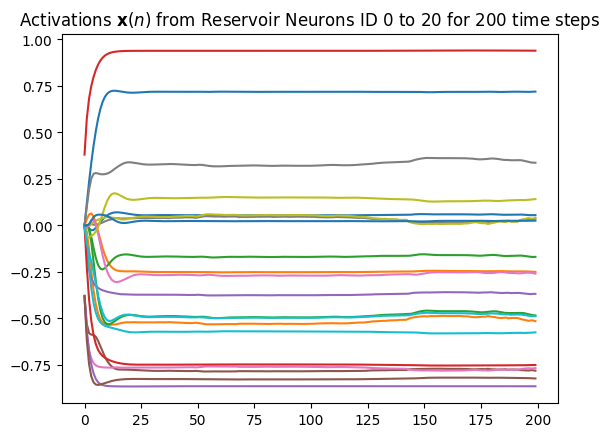

Mean Absolute Error (MAE): 0.0107
Root Mean Squared Error (RMSE): 0.0154
Mean Absolute Percentage Error (MAPE): 1.3185%
R-squared: 0.9819

********************
Errors computed over 608 time steps

Mean Squared error (MSE):	2.3694e-04
Root Mean Squared error (RMSE):	1.5393e-02
Normalized RMSE (based on mean):	1.9300e-02
Normalized RMSE (based on max - min):	3.6303e-02
********************


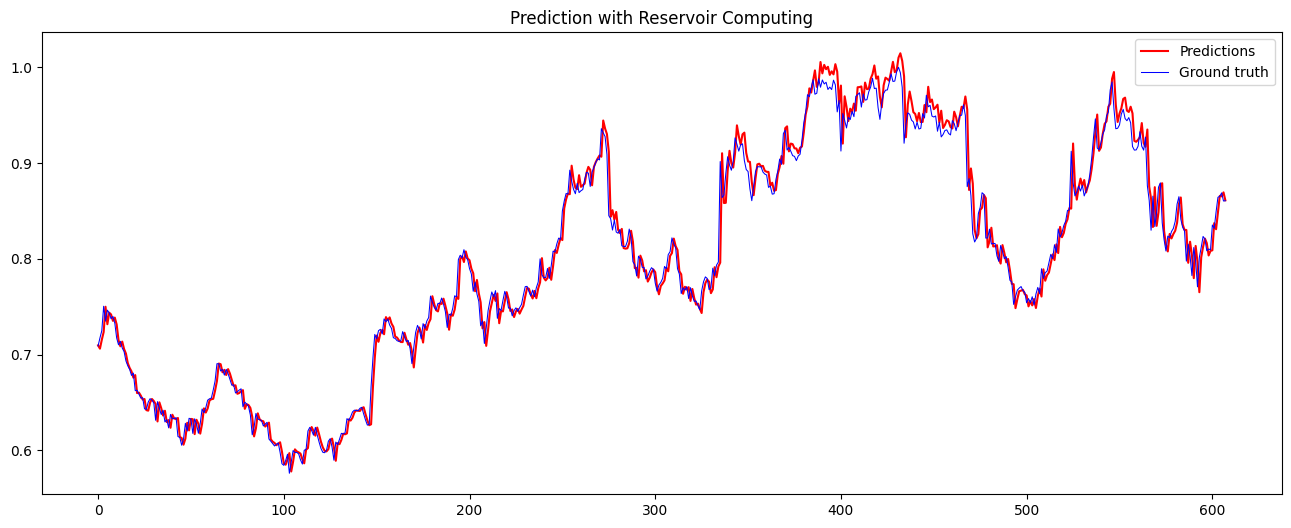

In [241]:
AMGN = train_rc_model(train, trade, 'AMGN', 'close', 1)

In [34]:
ticker_list

['AAPL',
 'AMGN',
 'AMZN',
 'AXP',
 'BA',
 'CAT',
 'CRM',
 'CSCO',
 'CVX',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'KO',
 'MCD',
 'MMM',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'SWH',
 'TRV',
 'UNH',
 'V',
 'VZ',
 'WMT']

In [ ]:
for x in ticker_list:
    rc = 

In [36]:
close_df = processed_full.pivot_table(index='date', columns='tic', values='close', aggfunc='mean')
close_df

tic,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,TRV,UNH,V,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2014-01-06,16.906864,82.310516,19.681499,76.188454,118.295074,65.567970,53.844185,15.506261,76.355698,68.926865,...,33.659000,30.082026,33.698708,0.374377,58.292801,68.772926,62.467445,50.689442,27.260458,20.714285
2014-01-07,16.785950,84.450264,19.901501,75.899666,120.089882,65.782463,54.559059,15.717610,77.002136,69.399605,...,33.909367,30.315155,33.724838,0.380507,58.856628,68.370743,64.377502,51.076817,27.601984,20.777857
2014-01-08,16.892246,84.051315,20.096001,76.138077,120.354828,65.937798,56.534901,15.703524,75.906219,68.381424,...,33.692825,29.773962,33.550747,0.385694,58.003632,67.736534,63.628620,51.240536,27.449167,20.613644
2014-01-09,16.676537,86.234573,20.050501,75.686760,121.474442,66.359444,55.889526,15.562621,75.906219,68.090523,...,33.510120,29.582464,33.550747,0.371313,58.133747,67.813881,64.015671,51.169064,26.883204,20.682501
2014-01-10,16.565268,85.581757,19.882999,75.405777,121.277885,66.951202,56.544830,15.654203,74.502541,68.535965,...,33.753735,30.007103,33.476772,0.370841,58.047001,67.666924,62.854515,50.989204,27.024700,20.669260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-11-22,158.043655,181.288895,178.628494,163.358154,209.899994,189.099518,294.728119,49.080318,99.103569,152.278809,...,73.560631,329.970734,165.079575,31.893887,135.555954,145.415649,415.899414,190.484085,41.271778,45.822628
2021-11-23,158.426422,182.898544,179.001999,163.310349,209.130005,191.855942,289.346710,49.709545,101.182907,149.186996,...,74.605843,327.883087,163.099472,31.684292,137.060089,148.558121,425.015106,193.318253,41.439938,46.148613
2021-11-24,158.946640,182.397766,179.020493,164.036789,210.600006,193.481766,287.112701,49.925285,101.957214,149.493225,...,74.137291,328.106323,162.985718,32.610489,136.344696,147.362289,427.895203,197.954224,41.367870,46.379658


In [38]:
def normalize_data(data):
    return (data - data.min()) / (data.max() - data.min())

In [39]:
def create_windowed_dataset(data, window, horizon):
    X, y = [], []
    for i in range(len(data) - window - horizon):
        X.append(data[i : i + window])
        y.append(data[i + window + horizon - 1])  # Predict horizon steps ahead
    return np.array(X), np.array(y)

Data dimensions (1990, 29)
max: 441.3833923339844 min: 0.362118124961853
mean: 98.49745073725623 std: 66.45401737617212


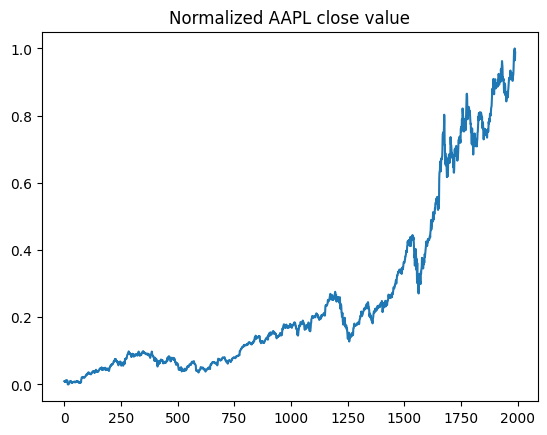

(1000, 10)
(1000, 1)
(979, 10)
(979, 1)


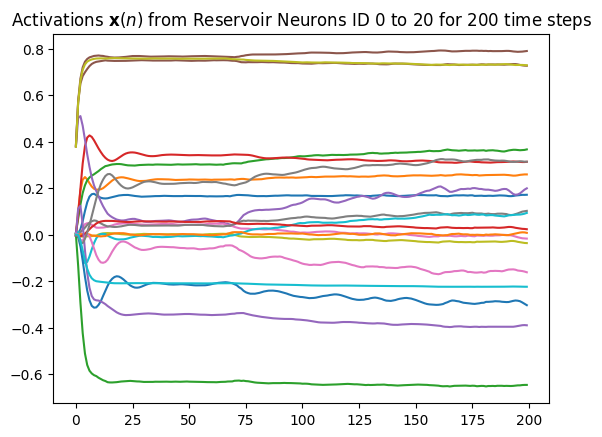

Mean Absolute Error (MAE): 0.2056
Root Mean Squared Error (RMSE): 0.3467
Mean Absolute Percentage Error (MAPE): 27.3293%
R-squared: -0.7052

********************
Errors computed over 100 time steps

Mean Squared error (MSE):	1.2021e-01
Root Mean Squared error (RMSE):	3.4672e-01
Normalized RMSE (based on mean):	7.7763e-01
Normalized RMSE (based on max - min):	3.9754e-01
********************


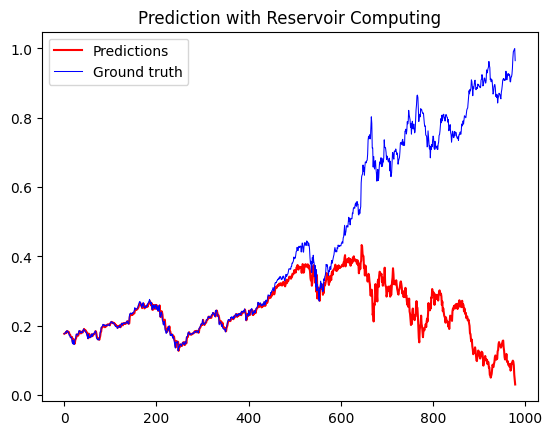

In [54]:
df=close_df
Dat = np.array(df)

# Set constants
window = 10
SEED = 42
VERBOSE = True
units = 10000
horizon = 1

if __name__ == "__main__":
    rpy.set_seed(SEED)
    rpy.verbosity(0)

    if VERBOSE:
        print("Data dimensions", Dat.shape)
        print("max:", Dat.max(), "min:", Dat.min())
        print("mean:", Dat.mean(), "std:", Dat.std())

    data = normalize_data(Dat[:,0])
    
    plt.figure()
    plt.plot(data)
    plt.title("Normalized AAPL close value")
    plt.show()

    train_size = 1000
    test_size = 100

    #X = data[:train_size].reshape(-1, 1)
    #y = data[horizon : train_size + horizon].reshape(-1, 1)
    #X_test = data[train_size : train_size + test_size].reshape(-1, 1)
    #y_test = data[train_size + horizon : train_size + test_size + horizon].reshape(-1, 1)

    # Generate full dataset
    X_all, y_all = create_windowed_dataset(data, window, horizon)

    X = X_all[:train_size]
    y = y_all[:train_size].reshape(-1, 1)

    X_test = X_all[train_size:]
    y_test = y_all[train_size:].reshape(-1, 1)

    print(X.shape)
    print(y.shape)
    print(X_test.shape)
    print(y_test.shape)

    # Reservoir parameters
    units = 20
    leak_rate = 0.5
    rho = 1.0
    input_scaling = 0.75
    rc_connectivity = 0.15
    input_connectivity = 0.2
    fb_connectivity = 1.1
    regularization_coef = 1e-6
    warmup = 200
    feedback = False

    rng = np.random.default_rng(SEED)
    W = rng.random((units, units)) - 0.5
    input_bias = True  # Set to True or False depending on your choice
    Win = rng.random((units, 1 + int(input_bias))) - 0.5
    Wfb = rng.random((units, 1)) - 0.5

    mask = rng.random((units, units))
    W[mask > rc_connectivity] = 0

    mask = rng.random((units, Win.shape[1]))
    Win[mask > input_connectivity] = 0

    mask = rng.random((units, Wfb.shape[1]))
    Wfb[mask > fb_connectivity] = 0

    Win = Win * input_scaling

    # Calculate the spectral radius
    original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

    # Rescale the matrix to reach the requested spectral radius:
    W = W * (rho / original_spectral_radius)

    # Create a reservoir
    reservoir = Reservoir(
        units,
        lr=leak_rate,
        sr=rho,
        input_bias=input_bias,
        input_scaling=input_scaling,
        rc_connectivity=rc_connectivity,
        input_connectivity=input_connectivity,
        fb_connectivity=fb_connectivity,
    )

    readout = Ridge(ridge=regularization_coef)

    if feedback:
        reservoir = reservoir << readout

    esn = reservoir >> readout

    internal_trained = reservoir.run(X)

    reservoir.reset()

    plt.figure()
    plt.plot(internal_trained[:200, :21])
    plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
    plt.show()

    esn = esn.fit(X, y, warmup=warmup)

    y_pred = esn.run(X_test)

    mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

    print("Mean Absolute Error (MAE): {:.4f}".format(mae))
    print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
    print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
    print("R-squared: {:.4f}".format(r2))
    print("\n********************")
    print(f"Errors computed over {test_size} time steps")
    print("\nMean Squared error (MSE):\t%.4e" % mse_score)
    print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
    print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
    print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
    print("********************")

    plt.figure()
    plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
    plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
    plt.title("Prediction with Reservoir Computing")
    plt.legend()
    plt.show()

end_time = time.time()

In [79]:
len(Dat[:,0])

4385

In [51]:
X_test

array([[0.17807177, 0.1708061 , 0.17085515, ..., 0.17483173, 0.17805538,
        0.17699175],
       [0.1708061 , 0.17085515, 0.17164064, ..., 0.17805538, 0.17699175,
        0.17695914],
       [0.17085515, 0.17164064, 0.16861324, ..., 0.17699175, 0.17695914,
        0.17689352],
       ...,
       [0.9238259 , 0.90404669, 0.9037043 , ..., 0.97214463, 0.99048683,
        0.99370357],
       [0.90404669, 0.9037043 , 0.91821382, ..., 0.99048683, 0.99370357,
        0.99637257],
       [0.9037043 , 0.91821382, 0.91828234, ..., 0.99370357, 0.99637257,
        1.        ]])

In [52]:
y_test

array([[0.17695914],
       [0.17689352],
       [0.17851362],
       [0.18147566],
       [0.1800029 ],
       [0.18476486],
       [0.18502673],
       [0.18371753],
       [0.18132833],
       [0.18139376],
       [0.17677903],
       [0.17168969],
       [0.17234425],
       [0.16653496],
       [0.16491483],
       [0.1656676 ],
       [0.1662404 ],
       [0.15432709],
       [0.14776506],
       [0.15846731],
       [0.15275612],
       [0.14557217],
       [0.14867759],
       [0.15902931],
       [0.16170749],
       [0.1666861 ],
       [0.1759204 ],
       [0.17500027],
       [0.17404723],
       [0.17276569],
       [0.17511526],
       [0.18004458],
       [0.18574622],
       [0.18479321],
       [0.18434948],
       [0.17922303],
       [0.18121121],
       [0.18221353],
       [0.18196701],
       [0.17927234],
       [0.18241064],
       [0.18740574],
       [0.19026471],
       [0.1873893 ],
       [0.1848753 ],
       [0.18522043],
       [0.18418523],
       [0.179

In [53]:
y_pred

array([[0.17677816],
       [0.17769185],
       [0.17805898],
       [0.17865547],
       [0.18204728],
       [0.1795691 ],
       [0.1842767 ],
       [0.1843477 ],
       [0.18295207],
       [0.18106674],
       [0.18151791],
       [0.1771342 ],
       [0.17295352],
       [0.17318333],
       [0.16763325],
       [0.16647889],
       [0.16700009],
       [0.16719936],
       [0.15578287],
       [0.15008274],
       [0.16065886],
       [0.15433005],
       [0.14699637],
       [0.14991168],
       [0.15948482],
       [0.16195078],
       [0.16564073],
       [0.17368319],
       [0.17478876],
       [0.17340322],
       [0.17107692],
       [0.17404693],
       [0.17995073],
       [0.18410718],
       [0.18203603],
       [0.18290389],
       [0.17755109],
       [0.1809363 ],
       [0.18240978],
       [0.1827998 ],
       [0.180374  ],
       [0.18389527],
       [0.18779615],
       [0.1906551 ],
       [0.18720553],
       [0.18589393],
       [0.18662215],
       [0.185